# Target Encoding (codificacion del objetivo)
Como ya hemos visto muchas veces, hemos visto solo funciones numericas, ahora, veremos funciones categoricas y metodos para trabajar con ellos como numeros.

## Target enconding
Es una tecnica que remplaza las funciones categoricas con numeros derivados del objetivo.

In [2]:
import pandas as pd
autos = pd.read_csv("data/autos.csv")
autos["make_encoded"] = autos.groupby("make")["price"].transform("mean")
autos[["make", "price", "make_encoded"]].head(10)

,make,price,make_encoded
0,alfa-romero,13495,15498.333333
1,alfa-romero,16500,15498.333333
2,alfa-romero,16500,15498.333333
3,audi,13950,17859.166667
4,audi,17450,17859.166667
5,audi,15250,17859.166667
6,audi,17710,17859.166667
7,audi,18920,17859.166667
8,audi,23875,17859.166667
9,bmw,16430,26118.750000


Lo que estamos haciendo es una vercion de como aplicar la agregacion por agrupacion, como para el promedio. El dataset de autos sirve muy bien para calcular el precio promedio de cada vehiculo.

## Smothing
Codificar de esta forma tiene sus riesgos, por ejemplo, no sabe muy bien que hacer con las categorias desconocidas, esto crea un riesgo especial para el overfitting, que quiere decir que nesecitan su propia codificacion. En segundo, las categorias raras tambien funcionan no tan bien. Cuando una categoria ocurre pocas veces, raras, proboca que la prediccion no se acerque, asi que esos datos es mejor descartarlos en algunas ocaciones.

Para solucionar parte de estos problemas es mejor utilizar Smothing.

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns


df = pd.read_csv("data/movielens1m.csv")
df = df.astype(np.uint8, errors='ignore') # reduce memory footprint
print("Number of Unique Zipcodes: {}".format(df["Zipcode"].nunique()))

Number of Unique Zipcodes: 3439


Con casi 3000 categorias, podemos decir que `Zipcode` es buen candidatos para las funciones.

In [12]:
X = df.copy()
y = X.pop("Rating")
X_encode = X.sample(frac = 0.25)
y_encode = y[X_encode.index]
X_pretrain = X.drop(X_encode.index)
y_train = y[X_pretrain.index]

La `category_encoders` empaqueta en `scikit-learn`. Implementa un m-estimate encoder, que usaremos para el `Zipcode`.

In [23]:
from category_encoders import MEstimateEncoder

# Create the encoder instance. Choose m to control noise.
encoder = MEstimateEncoder(cols=["Zipcode"], m=5.0)

# Fit the encoder on the encoding split.
encoder.fit(X_encode, y_encode)

# Encode the Zipcode column to create the final training data
X_train = encoder.transform(X_pretrain)

C:\Users\CDWLu\AppData\Local\Temp\ipykernel_12300\1844280021.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(y, kde=False, norm_hist=True)


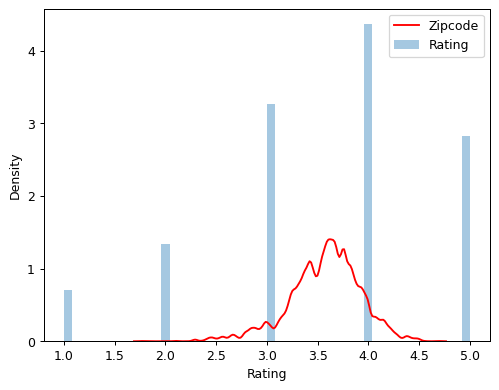

In [24]:
plt.figure(dpi=90)
ax = sns.distplot(y, kde=False, norm_hist=True)
ax = sns.kdeplot(X_train.Zipcode, color='r', ax=ax)
ax.set_xlabel("Rating")
ax.legend(labels=['Zipcode', 'Rating']);